In [ ]:
import pandas as pd
import numpy as np
import glob

## 0. Data Crawling

In [ ]:
REGIONS = [
    {"region": "Brussels", "latitude": 50.8503, "longitude": 4.3517},
    {"region": "Antwerp", "latitude": 51.2194, "longitude": 4.4025},
    {"region": "Ghent", "latitude": 51.0543, "longitude": 3.7174},
    {"region": "Bruges", "latitude": 51.2093, "longitude": 3.2247},
    {"region": "Liège", "latitude": 50.6326, "longitude": 5.5797},
    {"region": "Namur", "latitude": 50.4674, "longitude": 4.8720},
    {"region": "Charleroi", "latitude": 50.4108, "longitude": 4.4446},
    {"region": "Leuven", "latitude": 50.8798, "longitude": 4.7005},
    {"region": "Mons", "latitude": 50.4542, "longitude": 3.9563},
    {"region": "Hasselt", "latitude": 50.9307, "longitude": 5.3375},
    {"region": "Arlon", "latitude": 49.6835, "longitude": 5.8167},
    {"region": "Kortrijk", "latitude": 50.8279, "longitude": 3.2649},
    {"region": "Tournai", "latitude": 50.6058, "longitude": 3.3883},
    {"region": "Ostend", "latitude": 51.2254, "longitude": 2.9263},
    {"region": "Wavre", "latitude": 50.7159, "longitude": 4.6105},
]

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

HOURLY_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "wind_speed_10m",
    "wind_direction_10m",
    "pressure_msl",
    "cloud_cover",
]

## 1. Data Preprocessing

### 1.1 Traffic count

In [ ]:
#Loading traffic data
traffic_columns=['site_id', 'direction', 'type', 'from', 'to', 'count']
traffic_files = sorted(glob.glob("/home/test/mda/mda_project/data/traffic/data-*.csv"))
df_traffic = pd.concat([pd.read_csv(f, header=None, names=traffic_columns) for f in traffic_files], ignore_index=True)
print(f"{len(df_traffic):,} rows from {len(traffic_files)} files")

41,344,152 rows from 80 files


In [ ]:
#Filter out rows with missing counts
df_traffic = df_traffic[df_traffic['count'].isna() == False]

In [ ]:
#Convert data types and extract datetime features
df_traffic["from"] = pd.to_datetime(df_traffic["from"])
df_traffic["to"]   = pd.to_datetime(df_traffic["to"])

df_traffic["year"]   = df_traffic["from"].dt.year
df_traffic["month"]  = df_traffic["from"].dt.month
df_traffic["day"]    = df_traffic["from"].dt.day
df_traffic["hour"]   = df_traffic["from"].dt.hour
df_traffic["minute"] = df_traffic["from"].dt.minute

df_traffic["site_id"]   = df_traffic["site_id"].astype("int32")
df_traffic["count"]     = df_traffic["count"].astype("float32")
df_traffic["direction"] = df_traffic["direction"].astype("category")
df_traffic["type"]      = df_traffic["type"].astype("category")
# df_traffic["quarter"]   = df_traffic["quarter"].astype("category")

df_traffic.info()

<class 'pandas.DataFrame'>
Index: 40275581 entries, 0 to 41344151
Data columns (total 11 columns):
 #   Column     Dtype         
---  ------     -----         
 0   site_id    int32         
 1   direction  category      
 2   type       category      
 3   from       datetime64[us]
 4   to         datetime64[us]
 5   count      float32       
 6   year       int32         
 7   month      int32         
 8   day        int32         
 9   hour       int32         
 10  minute     int32         
dtypes: category(2), datetime64[us](2), float32(1), int32(6)
memory usage: 2.0 GB


In [ ]:
#Pivot table to calculate traffic for each hour instead of 15 minute time frame
quarter_map = {0: "00_15", 15: "15_30", 30: "30_45", 45: "45_60"}
df_traffic["quarter"] = df_traffic["from"].dt.minute.map(quarter_map)


df_traffic_hourly = df_traffic.pivot_table(
    index=["site_id", "year","month","day", "hour","type"],
    columns=["direction", "quarter"],
    values="count",
    aggfunc="sum",
    fill_value=0,
)
df_traffic_hourly.columns = [f"{d}_{q}" for d, q in df_traffic_hourly.columns]
df_traffic_hourly = df_traffic_hourly.reset_index()
df_traffic_hourly.head()

,site_id,year,month,day,hour,type,IN_00_15,IN_15_30,IN_30_45,IN_45_60,OUT_00_15,OUT_15_30,OUT_30_45,OUT_45_60
0,1,2019,8,1,0,FIETSERS,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1,2019,8,1,1,FIETSERS,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2019,8,1,2,FIETSERS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1,2019,8,1,3,FIETSERS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2019,8,1,4,FIETSERS,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [ ]:
#Feature Engineering for traffic data
count_cols = [c for c in df_traffic_hourly.columns if c not in ("site_id", "year", "month", "day", "hour", "type")]
in_cols    = [c for c in count_cols if c.startswith("IN_")]
out_cols   = [c for c in count_cols if c.startswith("OUT_")]

df_traffic_hourly["total_in"]   = df_traffic_hourly[in_cols].sum(axis=1)
df_traffic_hourly["total_out"]  = df_traffic_hourly[out_cols].sum(axis=1)
df_traffic_hourly["total"]      = df_traffic_hourly["total_in"] + df_traffic_hourly["total_out"]
df_traffic_hourly["net_flow"]   = df_traffic_hourly["total_in"] - df_traffic_hourly["total_out"]

df_traffic_hourly["min_q"]      = df_traffic_hourly[count_cols].min(axis=1)
df_traffic_hourly["max_q"]      = df_traffic_hourly[count_cols].max(axis=1)
df_traffic_hourly["mean_q"]     = df_traffic_hourly[count_cols].mean(axis=1)
df_traffic_hourly["median_q"]   = df_traffic_hourly[count_cols].median(axis=1)
df_traffic_hourly["std_q"]      = df_traffic_hourly[count_cols].std(axis=1)
df_traffic_hourly["range_q"]    = df_traffic_hourly["max_q"] - df_traffic_hourly["min_q"]

# Add datetime features
df_traffic_hourly["datehour"] = pd.to_datetime(df_traffic_hourly[["year", "month", "day", "hour"]])
df_traffic_hourly["date"] = pd.to_datetime(df_traffic_hourly[["year", "month", "day"]])
df_traffic_hourly["dayofweek"]   = df_traffic_hourly["date"].dt.dayofweek      # 0=Mon, 6=Sun
df_traffic_hourly["is_weekend"]  = df_traffic_hourly["dayofweek"].isin([5, 6]).astype(int)

print(df_traffic_hourly.head())
print("Shape:", df_traffic_hourly.shape)
print("Columns:", df_traffic_hourly.columns.tolist())

   site_id  year  month  day  hour      type  IN_00_15  IN_15_30  IN_30_45  \
0        1  2019      8    1     0  FIETSERS       0.0       0.0       0.0   
1        1  2019      8    1     1  FIETSERS       1.0       0.0       0.0   
2        1  2019      8    1     2  FIETSERS       0.0       0.0       1.0   
3        1  2019      8    1     3  FIETSERS       0.0       0.0       0.0   
4        1  2019      8    1     4  FIETSERS       0.0       0.0       0.0   

   IN_45_60  ...  min_q  max_q  mean_q  median_q     std_q  range_q  \
0       0.0  ...    0.0    1.0   0.250       0.0  0.462910      1.0   
1       0.0  ...    0.0    1.0   0.125       0.0  0.353553      1.0   
2       0.0  ...    0.0    1.0   0.125       0.0  0.353553      1.0   
3       0.0  ...    0.0    0.0   0.000       0.0  0.000000      0.0   
4       0.0  ...    0.0    1.0   0.250       0.0  0.462910      1.0   

             datehour       date  dayofweek  is_weekend  
0 2019-08-01 00:00:00 2019-08-01          3   

## 1.1.1 Exploratory Data Analysis

In [ ]:
print("Shape:", df_traffic_hourly.shape)
print("Memory usage MB:", round(df_traffic_hourly.memory_usage(deep=True).sum() / 1e6, 2))
print("Date range:", df_traffic_hourly["datehour"].min(), "to", df_traffic_hourly["datehour"].max())
print("Unique sites:", df_traffic_hourly["site_id"].nunique())

print("\nMissing values:")
print(df_traffic_hourly.isna().sum().sort_values(ascending=False).head(20))

print("\nTraffic distribution:")
eda_target_cols = [c for c in ["total_in", "total_out", "total", "net_flow"] if c in df_traffic_hourly.columns]
df_traffic_hourly[eda_target_cols].describe()

Shape: (5043289, 28)
Memory usage MB: 610.24
Date range: 2019-08-01 00:00:00 to 2026-03-14 03:00:00
Unique sites: 149

Missing values:
site_id      0
year         0
month        0
day          0
hour         0
type         0
IN_00_15     0
IN_15_30     0
IN_30_45     0
IN_45_60     0
OUT_00_15    0
OUT_15_30    0
OUT_30_45    0
OUT_45_60    0
total_in     0
total_out    0
total        0
net_flow     0
min_q        0
max_q        0
dtype: int64

Traffic distribution:


,total_in,total_out,total,net_flow
count,5.043289e+06,5.043289e+06,5.043289e+06,5.043289e+06
mean,1.072585e+01,9.803412e+00,2.052926e+01,9.224346e-01
std,2.607559e+01,2.379249e+01,4.336478e+01,2.472922e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.498000e+03
25%,0.000000e+00,0.000000e+00,2.000000e+00,-3.000000e+00
50%,2.000000e+00,2.000000e+00,7.000000e+00,0.000000e+00
75%,1.100000e+01,1.000000e+01,2.200000e+01,4.000000e+00
max,5.422000e+03,4.479000e+03,9.901000e+03,4.738000e+03


### 1.2. Richtingen

In [ ]:
#Loading directions data
richtingen_columns=['site_id', 'direction', 'name']
df_richtingen = pd.read_csv('/home/test/mda/mda_project/data/richtingen.csv', header=0, names=richtingen_columns)
df_richtingen.head()

,site_id,direction,name
0,1,OUT,Machelen Cyclists richting Machelen
1,2,IN,Brasschaat 2 Fietsers rich Merksem
2,2,OUT,Brasschaat 2 Fietsers rich Brasschaat
3,3,IN,Brasschaat 1 Fietsers rich Merksem
4,3,OUT,Brasschaat 1 Fietsers rich Brasschaat


In [ ]:
df_richtingen.info()
df_richtingen.shape

<class 'pandas.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   site_id    304 non-null    int64
 1   direction  304 non-null    str  
 2   name       304 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.7 KB


(304, 3)

In [ ]:
#Filter to only include IN and OUT directions
df_richtingen = df_richtingen[df_richtingen['direction'].isin(['IN', 'OUT'])]
df_richtingen.shape

(300, 3)

### 1.3. Sites

In [ ]:
#Loading sites data
sites_columns=['site_id', 'site_nr', 'longtitude', 'latitude', 'name', 'domain', 'road_nbr','district_nbr', 'municipality', 'interval', 'date_installed']
df_sites = pd.read_csv('/home/test/mda/mda_project/data/sites.csv', header=0, names=sites_columns)
df_sites.head()

,site_id,site_nr,longtitude,latitude,name,domain,road_nbr,district_nbr,municipality,interval,date_installed
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,2019-08-22


In [ ]:

REGIONS_DF = pd.DataFrame(REGIONS)

def haversine_km(lat1, lon1, lat2, lon2):
    """Calculate the Haversine (km) distance."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

# Distance matrix: 150 sites × 15 regions
site_lat = df_sites["latitude"].to_numpy()[:, None]    # column (150, 1)
site_lon = df_sites["longtitude"].to_numpy()[:, None]
reg_lat  = REGIONS_DF["latitude"].to_numpy()[None, :]  # row (1, 15)
reg_lon  = REGIONS_DF["longitude"].to_numpy()[None, :]

dist = haversine_km(site_lat, site_lon, reg_lat, reg_lon)   # shape (150, 15)

# For each site, select the nearest region and its distance
nearest_idx = dist.argmin(axis=1)
df_sites["region"]         = REGIONS_DF["region"].to_numpy()[nearest_idx]
df_sites["region_dist_km"] = dist[np.arange(len(df_sites)), nearest_idx].round(2)

df_sites.head()

,site_id,site_nr,longtitude,latitude,name,domain,road_nbr,district_nbr,municipality,interval,date_installed,region,region_dist_km
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22,Antwerp,7.85
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22,Antwerp,7.86
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,Hasselt,27.52
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22,Hasselt,27.52
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,2019-08-22,Ghent,6.16


### Neighbor features

In [ ]:
# Order by site_id to ensure consistent order for distance matrix
sites = df_sites[["site_id", "latitude", "longtitude"]].drop_duplicates("site_id")
sites = sites.sort_values("site_id").reset_index(drop=True)

ids = sites["site_id"].to_numpy()
lat = sites["latitude"].to_numpy()
lon = sites["longtitude"].to_numpy()

# Haversine for all pairs (vectorized)
R = 6371.0
lat_rad = np.radians(lat)
lon_rad = np.radians(lon)
dlat = lat_rad[:, None] - lat_rad[None, :]
dlon = lon_rad[:, None] - lon_rad[None, :]
a = (np.sin(dlat / 2) ** 2
     + np.cos(lat_rad)[:, None] * np.cos(lat_rad)[None, :] * np.sin(dlon / 2) ** 2)
dist = 2 * R * np.arcsin(np.sqrt(a))

# Fill diagonal with infinity so that sites don't consider themselves as neighbors
np.fill_diagonal(dist, np.inf)

dist_df = pd.DataFrame(dist, index=ids, columns=ids)
print("Distance matrix shape:", dist_df.shape)
dist_df.iloc[:5, :5]

Distance matrix shape: (150, 150)


,2,3,4,5,6
2,inf,0.038202,51.641693,51.637696,56.666380
3,0.038202,inf,51.603499,51.599502,56.698085
4,51.641693,51.603499,inf,0.007876,103.917928
5,51.637696,51.599502,0.007876,inf,103.912106
6,56.666380,56.698085,103.917928,103.912106,inf


In [ ]:
### EDA distances to neighbors to decide on good k and radius values for neighbor features
# # 1. Distribution of distances to 1st nearest neighbor
nearest_distances_km = dist_df.min(axis=1).sort_values()
print(nearest_distances_km.describe())

# Distribution by quantiles
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  {q*100:>5.0f}%: {nearest_distances_km.quantile(q):>7.2f} km")


# 2. Distribution of distances to kth nearest neighbor
print(f"{'K':>3}  {'min':>7}  {'25%':>7}  {'median':>7}  {'75%':>7}  {'max':>7}")
for k in [1, 2, 3, 5, 10, 20]:
    kth_distances = dist_df.apply(lambda row: row.nsmallest(k).iloc[-1], axis=1)
    print(f"{k:>3}  "
          f"{kth_distances.min():>7.2f}  "
          f"{kth_distances.quantile(0.25):>7.2f}  "
          f"{kth_distances.median():>7.2f}  "
          f"{kth_distances.quantile(0.75):>7.2f}  "
          f"{kth_distances.max():>7.2f}")


# 3. Number of neighbors obtained at each radius threshold
candidate_radii_km = [0.1, 0.2, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0]
print(f"{'Radius':>8}  {'mean':>5}  {'median':>6}  {'max':>3}  {'sites_iso':>10}  {'iso%':>5}")
for r_km in candidate_radii_km:
    counts_per_site = (dist_df <= r_km).sum(axis=1)   # number of neighbors per site
    n_isolated = (counts_per_site == 0).sum()
    print(f"{r_km:>6.1f}km  "
          f"{counts_per_site.mean():>5.1f}  "
          f"{int(counts_per_site.median()):>6d}  "
          f"{counts_per_site.max():>3d}  "
          f"{n_isolated:>10d}  "
          f"{n_isolated/len(counts_per_site)*100:>4.0f}%")

count    150.000000
mean       1.107539
std        2.523962
min        0.000000
25%        0.017369
50%        0.042283
75%        0.148770
max       12.249400
dtype: float64
     10%:    0.01 km
     25%:    0.02 km
     50%:    0.04 km
     75%:    0.15 km
     90%:    4.70 km
     95%:    7.68 km
     99%:   11.13 km
  K      min      25%   median      75%      max
  1     0.00     0.02     0.04     0.15    12.25
  2     0.07     2.80     5.57     9.12    18.04
  3     0.86     4.29     7.10    10.58    18.59
  5     2.59     9.14    10.85    13.52    26.45
 10     8.15    14.54    16.81    19.66    32.21
 20    13.97    21.21    24.64    30.71    41.68
  Radius   mean  median  max   sites_iso   iso%
   0.1km    0.7       1    2          45    30%
   0.2km    0.8       1    2          34    23%
   0.5km    0.8       1    2          34    23%
   1.0km    0.9       1    3          30    20%
   2.0km    1.1       1    4          24    16%
   3.0km    1.3       1    6          22    15%

Rationale for choosing 5 nearest neighbors and within distance of 200m, 5km and 10km:
 * 75% sites has neighbors within 150m, so 200m radius can cover this group
 * 90% sites has neighbors within 5km, which are isolated sites in small cities and represents characteristics in the same neighborhood in those cities
 * 99% sites has neighbors within 11km

In [ ]:
K=5
RADII_M = [200,5000,10000]
RADII_KM = [r / 1000 for r in RADII_M]   # [0.1, 0.2, 0.5, 1.0, 2.0]

# For each site, find its K nearest neighbors and neighbors within each radius threshold
# radius_maps[radius_m][site_id] = [list site within that radius]
radius_maps = {r_m: {} for r_m in RADII_M}
knn_map = {}
for site in ids:
    ordered = dist_df.loc[site].sort_values()
    for r_m, r_km in zip(RADII_M, RADII_KM):
        knn_map[site] = ordered.head(K).index.tolist()
        radius_maps[r_m][site] = ordered[ordered <= r_km].index.tolist()

# Example
for r_m in RADII_M:
    print(f"Site 2 — neighbor in {r_m}m:", radius_maps[r_m][2])

Site 2 — neighbor in 200m: [3]
Site 2 — neighbor in 5000m: [3]
Site 2 — neighbor in 10000m: [3]


In [ ]:
# Wide format: each column is a site, each row is a datehour
traffic_wide = df_traffic_hourly.pivot_table(
    index="datehour",
    columns="site_id",
    values="total",
    aggfunc="sum",
).sort_index()

# Shift 1 hour — neighbor traffic of previous hour to avoid leakage
LAG = 1
traffic_wide_lag = traffic_wide.shift(LAG)

print("Wide traffic shape:", traffic_wide.shape)
traffic_wide.head()

Wide traffic shape: (58006, 149)


site_id,1,2,3,4,5,6,7,8,9,10,...,142,143,145,146,147,148,149,150,151,152
datehour,,,,,,,,,,,,,,,,,,,,,
2019-08-01 00:00:00,2.0,2.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01 01:00:00,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01 02:00:00,1.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01 03:00:00,0.0,0.0,2.0,0.0,2.0,3.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01 04:00:00,2.0,3.0,3.0,0.0,1.0,2.0,0.0,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
parts = []
nan_template = pd.Series(np.nan, index=traffic_wide_lag.index)

# Historical average traffic per site, used to describe the usual traffic level
# of the first 5 nearest neighbours
hist_traffic_mean_by_site = df_traffic_hourly.groupby("site_id")["total"].mean()

for site in ids:
    row_dict = {
        "site_id":  site,
        "datehour": traffic_wide_lag.index,
    }

    # (1) kNN features: 5 nearest sites
    knn_cols = [s for s in knn_map[site] if s in traffic_wide_lag.columns]
    if knn_cols:
        sub = traffic_wide_lag[knn_cols]
        row_dict[f"nb_knn{K}_lag{LAG}_mean"] = sub.mean(axis=1).values
        row_dict[f"nb_knn{K}_lag{LAG}_max"]  = sub.max(axis=1).values
        row_dict[f"nb_knn{K}_lag{LAG}_sum"]  = sub.sum(axis=1).values
        row_dict[f"nb_knn{K}_lag{LAG}_std"]  = sub.std(axis=1).values
    else:
        for stat in ("mean", "max", "sum", "std"):
            row_dict[f"nb_knn{K}_lag{LAG}_{stat}"] = nan_template.values

    # (2) Historical traffic features: first 5 nearest neighbours
    first_5_neighbors = [s for s in knn_map[site][:5] if s in hist_traffic_mean_by_site.index]
    for idx in range(1, 6):
        if idx <= len(first_5_neighbors):
            row_dict[f"nb_{idx}_hist_traffic_mean"] = hist_traffic_mean_by_site.loc[first_5_neighbors[idx - 1]]
        else:
            row_dict[f"nb_{idx}_hist_traffic_mean"] = np.nan

    row_dict["nb_5_hist_traffic_mean_avg"] = np.mean([
        row_dict["nb_1_hist_traffic_mean"],
        row_dict["nb_2_hist_traffic_mean"],
        row_dict["nb_3_hist_traffic_mean"],
        row_dict["nb_4_hist_traffic_mean"],
        row_dict["nb_5_hist_traffic_mean"]
    ])

    # (3) Radius features: site in each radii
    for r_m in RADII_M:
        rad_cols = [s for s in radius_maps[r_m][site] if s in traffic_wide_lag.columns]
        prefix = f"nb_r{r_m}m_lag{LAG}"

        if rad_cols:
            sub = traffic_wide_lag[rad_cols]
            row_dict[f"{prefix}_mean"] = sub.mean(axis=1).values
            row_dict[f"{prefix}_max"]  = sub.max(axis=1).values
            row_dict[f"{prefix}_sum"]  = sub.sum(axis=1).values
            row_dict[f"{prefix}_std"]  = sub.std(axis=1).values
        else:
            for stat in ("mean", "max", "sum", "std"):
                row_dict[f"{prefix}_{stat}"] = nan_template.values

        row_dict[f"nb_r{r_m}m_count"] = len(rad_cols)

    parts.append(pd.DataFrame(row_dict))

fts_neighbor_lag1 = pd.concat(parts, ignore_index=True)
print("\nNeighbor features shape:", fts_neighbor_lag1.shape)
print("Number of columns:", len(fts_neighbor_lag1.columns))
print("\nColumns:")
print(fts_neighbor_lag1.columns.tolist())
fts_neighbor_lag1.head()


Neighbor features shape: (8700900, 27)
Number of columns: 27

Columns:
['site_id', 'datehour', 'nb_knn5_lag1_mean', 'nb_knn5_lag1_max', 'nb_knn5_lag1_sum', 'nb_knn5_lag1_std', 'nb_1_hist_traffic_mean', 'nb_2_hist_traffic_mean', 'nb_3_hist_traffic_mean', 'nb_4_hist_traffic_mean', 'nb_5_hist_traffic_mean', 'nb_5_hist_traffic_mean_avg', 'nb_r200m_lag1_mean', 'nb_r200m_lag1_max', 'nb_r200m_lag1_sum', 'nb_r200m_lag1_std', 'nb_r200m_count', 'nb_r5000m_lag1_mean', 'nb_r5000m_lag1_max', 'nb_r5000m_lag1_sum', 'nb_r5000m_lag1_std', 'nb_r5000m_count', 'nb_r10000m_lag1_mean', 'nb_r10000m_lag1_max', 'nb_r10000m_lag1_sum', 'nb_r10000m_lag1_std', 'nb_r10000m_count']


,site_id,datehour,nb_knn5_lag1_mean,nb_knn5_lag1_max,nb_knn5_lag1_sum,nb_knn5_lag1_std,nb_1_hist_traffic_mean,nb_2_hist_traffic_mean,nb_3_hist_traffic_mean,nb_4_hist_traffic_mean,...,nb_r5000m_lag1_mean,nb_r5000m_lag1_max,nb_r5000m_lag1_sum,nb_r5000m_lag1_std,nb_r5000m_count,nb_r10000m_lag1_mean,nb_r10000m_lag1_max,nb_r10000m_lag1_sum,nb_r10000m_lag1_std,nb_r10000m_count
0,2,2019-08-01 00:00:00,NaN,NaN,0.0,NaN,27.552542,7.978862,7.802289,13.164536,...,NaN,NaN,0.0,NaN,1,NaN,NaN,0.0,NaN,1
1,2,2019-08-01 01:00:00,3.0,3.0,3.0,NaN,27.552542,7.978862,7.802289,13.164536,...,3.0,3.0,3.0,NaN,1,3.0,3.0,3.0,NaN,1
2,2,2019-08-01 02:00:00,0.0,0.0,0.0,NaN,27.552542,7.978862,7.802289,13.164536,...,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1
3,2,2019-08-01 03:00:00,3.0,3.0,3.0,NaN,27.552542,7.978862,7.802289,13.164536,...,3.0,3.0,3.0,NaN,1,3.0,3.0,3.0,NaN,1
4,2,2019-08-01 04:00:00,2.0,2.0,2.0,NaN,27.552542,7.978862,7.802289,13.164536,...,2.0,2.0,2.0,NaN,1,2.0,2.0,2.0,NaN,1


In [ ]:
fts_neighbor_lag1.head()

,site_id,datehour,nb_knn5_lag1_mean,nb_knn5_lag1_max,nb_knn5_lag1_sum,nb_knn5_lag1_std,nb_1_hist_traffic_mean,nb_2_hist_traffic_mean,nb_3_hist_traffic_mean,nb_4_hist_traffic_mean,...,nb_r5000m_lag1_mean,nb_r5000m_lag1_max,nb_r5000m_lag1_sum,nb_r5000m_lag1_std,nb_r5000m_count,nb_r10000m_lag1_mean,nb_r10000m_lag1_max,nb_r10000m_lag1_sum,nb_r10000m_lag1_std,nb_r10000m_count
0,2,2019-08-01 00:00:00,NaN,NaN,0.0,NaN,27.552542,7.978862,7.802289,13.164536,...,NaN,NaN,0.0,NaN,1,NaN,NaN,0.0,NaN,1
1,2,2019-08-01 01:00:00,3.0,3.0,3.0,NaN,27.552542,7.978862,7.802289,13.164536,...,3.0,3.0,3.0,NaN,1,3.0,3.0,3.0,NaN,1
2,2,2019-08-01 02:00:00,0.0,0.0,0.0,NaN,27.552542,7.978862,7.802289,13.164536,...,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1
3,2,2019-08-01 03:00:00,3.0,3.0,3.0,NaN,27.552542,7.978862,7.802289,13.164536,...,3.0,3.0,3.0,NaN,1,3.0,3.0,3.0,NaN,1
4,2,2019-08-01 04:00:00,2.0,2.0,2.0,NaN,27.552542,7.978862,7.802289,13.164536,...,2.0,2.0,2.0,NaN,1,2.0,2.0,2.0,NaN,1


In [ ]:
# fts_neighbor_lag1.to_csv("/home/test/mda/mda_project/data/fts_neighbor.csv", index=False)

In [ ]:
fts_neighbor_lag1.isna().sum()

site_id                             0
datehour                            0
nb_knn5_lag1_mean             1711525
nb_knn5_lag1_max              1711525
nb_knn5_lag1_sum                    0
nb_knn5_lag1_std              3025053
nb_1_hist_traffic_mean              0
nb_2_hist_traffic_mean              0
nb_3_hist_traffic_mean              0
nb_4_hist_traffic_mean              0
nb_5_hist_traffic_mean         812084
nb_5_hist_traffic_mean_avg     812084
nb_r200m_lag1_mean            4769318
nb_r200m_lag1_max             4769318
nb_r200m_lag1_sum             2030210
nb_r200m_lag1_std             8356363
nb_r200m_count                      0
nb_r5000m_lag1_mean           3703412
nb_r5000m_lag1_max            3703412
nb_r5000m_lag1_sum             812084
nb_r5000m_lag1_std            6384712
nb_r5000m_count                     0
nb_r10000m_lag1_mean          2604661
nb_r10000m_lag1_max           2604661
nb_r10000m_lag1_sum            174018
nb_r10000m_lag1_std           4433375
nb_r10000m_c

In [ ]:
fts_neighbor_lag1.columns

Index(['site_id', 'datehour', 'nb_knn5_lag1_mean', 'nb_knn5_lag1_max',
       'nb_knn5_lag1_sum', 'nb_knn5_lag1_std', 'nb_1_hist_traffic_mean',
       'nb_2_hist_traffic_mean', 'nb_3_hist_traffic_mean',
       'nb_4_hist_traffic_mean', 'nb_5_hist_traffic_mean',
       'nb_5_hist_traffic_mean_avg', 'nb_r200m_lag1_mean', 'nb_r200m_lag1_max',
       'nb_r200m_lag1_sum', 'nb_r200m_lag1_std', 'nb_r200m_count',
       'nb_r5000m_lag1_mean', 'nb_r5000m_lag1_max', 'nb_r5000m_lag1_sum',
       'nb_r5000m_lag1_std', 'nb_r5000m_count', 'nb_r10000m_lag1_mean',
       'nb_r10000m_lag1_max', 'nb_r10000m_lag1_sum', 'nb_r10000m_lag1_std',
       'nb_r10000m_count'],
      dtype='str')

### 1.3.2. Neighbor features (previous 15 mins)

In [ ]:

# Step 1: 15-min FIETSERS traffic, summed across directions
df_traffic_fiets_15min = (
    df_traffic[df_traffic["type"] == "FIETSERS"]
    .groupby(["site_id", "from"], as_index=False)["count"]
    .sum()
    .rename(columns={"count": "total_fiets_15min"})
)

# Step 2: Wide matrix (rows = 15-min timestamp, cols = site_id)
traffic_wide_15min = df_traffic_fiets_15min.pivot_table(
    index="from",
    columns="site_id",
    values="total_fiets_15min",
    aggfunc="sum",
).sort_index()
traffic_wide_15min.index.name = "ts"

# Step 3: Shift by 1 period (15 min) → previous 15-min traffic
# Row at ts=T in shifted table = original traffic at ts=(T-15min)
traffic_wide_15min_shifted = traffic_wide_15min.shift(1)

# Step 4: Keep only on-the-hour rows to align with datehour
# Row at ts=14:00 (minute==0) after shift = traffic from 13:45-14:00
traffic_wide_prev15 = traffic_wide_15min_shifted[
    traffic_wide_15min_shifted.index.minute == 0
].copy()
traffic_wide_prev15.index.name = "datehour"

print(f"15-min-lagged hourly cyclist traffic table: {traffic_wide_prev15.shape}")
print(f"  date range: {traffic_wide_prev15.index.min()} → {traffic_wide_prev15.index.max()}")
traffic_wide_prev15.head()


15-min-lagged hourly cyclist traffic table: (58006, 149)
  date range: 2019-08-01 00:00:00 → 2026-03-14 03:00:00


site_id,1,2,3,4,5,6,7,8,9,10,...,142,143,145,146,147,148,149,150,151,152
datehour,,,,,,,,,,,,,,,,,,,,,
2019-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01 03:00:00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# For each site & datehour: calculate mean / max / sum / std of FIETSERS traffic
# across neighbors within 200 m, 5 km, and 10 km in the previous 15 min.


parts_15m = []
nan_tpl = pd.Series(np.nan, index=traffic_wide_prev15.index)

for site in ids:
    row = {
        "site_id":  site,
        "datehour": traffic_wide_prev15.index,
    }

    for r_m in RADII_M:
        rad_cols = [s for s in radius_maps[r_m][site]
                    if s in traffic_wide_prev15.columns]
        pfx = f"nb_r{r_m}m_lag15m"

        if rad_cols:
            sub = traffic_wide_prev15[rad_cols]
            row[f"{pfx}_mean"] = sub.mean(axis=1).values
            row[f"{pfx}_max"]  = sub.max(axis=1).values
            row[f"{pfx}_sum"]  = sub.sum(axis=1).values
            row[f"{pfx}_std"]  = sub.std(axis=1).values
        else:
            for stat in ("mean", "max", "sum", "std"):
                row[f"{pfx}_{stat}"] = nan_tpl.values

        # static: how many cyclist-reporting neighbors exist within this radius
        row[f"nb_r{r_m}m_lag15m_count"] = len(rad_cols)

    parts_15m.append(pd.DataFrame(row))

fts_neighbor_lag15m = pd.concat(parts_15m, ignore_index=True)
print("\n15-min neighbor features shape:", fts_neighbor_lag15m.shape)
print("Columns:", fts_neighbor_lag15m.columns.tolist())
fts_neighbor_lag15m.head()



15-min neighbor features shape: (8700900, 17)
Columns: ['site_id', 'datehour', 'nb_r200m_lag15m_mean', 'nb_r200m_lag15m_max', 'nb_r200m_lag15m_sum', 'nb_r200m_lag15m_std', 'nb_r200m_lag15m_count', 'nb_r5000m_lag15m_mean', 'nb_r5000m_lag15m_max', 'nb_r5000m_lag15m_sum', 'nb_r5000m_lag15m_std', 'nb_r5000m_lag15m_count', 'nb_r10000m_lag15m_mean', 'nb_r10000m_lag15m_max', 'nb_r10000m_lag15m_sum', 'nb_r10000m_lag15m_std', 'nb_r10000m_lag15m_count']


,site_id,datehour,nb_r200m_lag15m_mean,nb_r200m_lag15m_max,nb_r200m_lag15m_sum,nb_r200m_lag15m_std,nb_r200m_lag15m_count,nb_r5000m_lag15m_mean,nb_r5000m_lag15m_max,nb_r5000m_lag15m_sum,nb_r5000m_lag15m_std,nb_r5000m_lag15m_count,nb_r10000m_lag15m_mean,nb_r10000m_lag15m_max,nb_r10000m_lag15m_sum,nb_r10000m_lag15m_std,nb_r10000m_lag15m_count
0,2,2019-08-01 00:00:00,NaN,NaN,0.0,NaN,1,NaN,NaN,0.0,NaN,1,NaN,NaN,0.0,NaN,1
1,2,2019-08-01 01:00:00,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1
2,2,2019-08-01 02:00:00,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1
3,2,2019-08-01 03:00:00,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1
4,2,2019-08-01 04:00:00,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1,0.0,0.0,0.0,NaN,1


### 1.4 Weather

In [ ]:
df_weather = pd.read_csv('/home/test/mda/belgium_weather_2019_2026.csv', header=0)
df_weather.head()

,region,latitude,longitude,datetime,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,pressure_msl,cloud_cover
0,Brussels,50.8503,4.3517,2019-08-01T00:00,15.9,74,0.0,0.0,0.0,13.0,214,1016.9,63
1,Brussels,50.8503,4.3517,2019-08-01T01:00,15.9,76,0.0,0.0,0.0,12.1,217,1017.1,56
2,Brussels,50.8503,4.3517,2019-08-01T02:00,15.4,80,0.0,0.0,0.0,12.6,211,1017.5,86
3,Brussels,50.8503,4.3517,2019-08-01T03:00,15.3,82,0.0,0.0,0.0,13.7,210,1017.2,76
4,Brussels,50.8503,4.3517,2019-08-01T04:00,15.9,79,0.0,0.0,0.0,15.5,216,1016.7,96


In [ ]:
df_weather = df_weather.rename(columns={"datetime": "datehour"})
df_weather["datehour"] = pd.to_datetime(df_weather["datehour"])

df_weather.head()

,region,latitude,longitude,datehour,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,pressure_msl,cloud_cover
0,Brussels,50.8503,4.3517,2019-08-01 00:00:00,15.9,74,0.0,0.0,0.0,13.0,214,1016.9,63
1,Brussels,50.8503,4.3517,2019-08-01 01:00:00,15.9,76,0.0,0.0,0.0,12.1,217,1017.1,56
2,Brussels,50.8503,4.3517,2019-08-01 02:00:00,15.4,80,0.0,0.0,0.0,12.6,211,1017.5,86
3,Brussels,50.8503,4.3517,2019-08-01 03:00:00,15.3,82,0.0,0.0,0.0,13.7,210,1017.2,76
4,Brussels,50.8503,4.3517,2019-08-01 04:00:00,15.9,79,0.0,0.0,0.0,15.5,216,1016.7,96


### 1.5. Population

In [ ]:
import rasterio
from rasterio.mask import geometry_mask
from rasterio.sample import sample_gen
import matplotlib.pyplot as plt

In [ ]:
TIF_PATH = "/home/test/mda/mda_project/data/extra/bel_pop_2025_CN_100m_R2025A_v1.tif"

# Open the file and extract all values at once
with rasterio.open(TIF_PATH) as src:
      print(f"CRS: {src.crs}")
      print(f"Bounds: {src.bounds}")
      print(f"Shape: {src.shape}")

      # Extract raster values for all sites (lat/long pairs)
      coords = list(zip(df_sites['longtitude'], df_sites['latitude']))

      # Sample the raster at all coordinates
      sampled_values = list(sample_gen(src, coords))

      # Get first band from each sampled point
      # df_sites['population'] = [val[0] for val in sampled_values]


CRS: EPSG:4326
Bounds: BoundingBox(left=2.5458326031499974, bottom=49.49750013801, right=6.407499254369998, top=51.50416679665)
Shape: (2408, 4634)


Size (rows, cols): (2408, 4634)
Number of bands              : 1
Data types          : ('float32',)
CRS       : EPSG:4326
Bounds       : BoundingBox(left=2.5458326031499974, bottom=49.49750013801, right=6.407499254369998, top=51.50416679665)
Resolution    : (0.00083333333, 0.00083333333)
NoData value:        -99999.0
Total estimated population: 11749843.0
Shape band 1: (2408, 4634)
Min/Max values: 0.0 461.33267


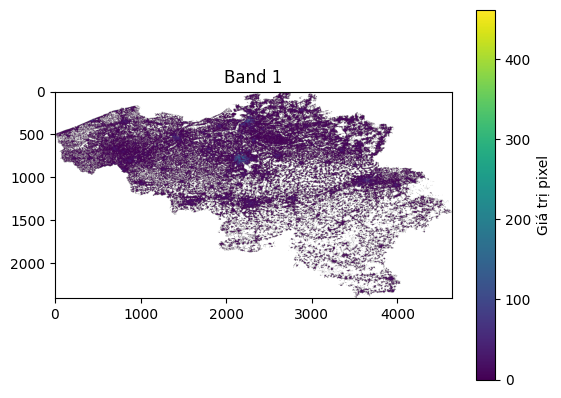

In [ ]:
with rasterio.open(TIF_PATH) as src:
    print("Size (rows, cols):", src.shape)
    print("Number of bands              :", src.count)
    print("Data types          :", src.dtypes)
    print("CRS       :", src.crs)
    print("Bounds       :", src.bounds)
    print("Resolution    :", src.res)
    print("NoData value:       ", src.nodata)

    # Read all data
    pop = src.read(1,masked=True)
    print("Total estimated population:", float(pop.sum()))
    # Read only band 1 (population)
    band1 = src.read(1,masked=True)

print("Shape band 1:", band1.shape)
print("Min/Max values:", band1.min(), band1.max())

# Visualize the population raster
plt.imshow(band1, cmap="viridis")
plt.colorbar(label="Giá trị pixel")
plt.title("Band 1")
plt.show()

### Calculate population using buffer

In [ ]:
sites_lat_long = df_sites[['site_id', 'latitude', 'longtitude']]

In [ ]:
import math
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
from shapely.ops import transform
from pyproj import Transformer


METRIC_CRS = "EPSG:3035"

def population_estimate(lat, lon, radius_m, tif_path=TIF_PATH):

    with rasterio.open(tif_path) as src:
        # 1. Covert (lat, lon) to m for accurate buffering
        to_metric = Transformer.from_crs("EPSG:4326", METRIC_CRS, always_xy=True)
        x_m, y_m = to_metric.transform(lon, lat)

        # 2. Create circle with radius_m meters
        circle = Point(x_m, y_m).buffer(radius_m)

        # 3. Transform circle to raster's CRS for masking
        to_raster = Transformer.from_crs(METRIC_CRS, src.crs, always_xy=True)
        circle_in_raster = transform(to_raster.transform, circle)

        # 4. Cut raster by circle, mask NoData automatically
        out, _ = mask(src, [circle_in_raster], crop=True, filled=False)

        total_pop = float(out.sum())                       # total population in the circle
        area_km2  = math.pi * (radius_m ** 2) / 1e6        # area of the circle in km²
        density   = total_pop / area_km2                   # population density in people/km²
        return total_pop, density, area_km2

rows = []
for loc in df_sites.itertuples():
    name, lat, lon = loc.site_id, loc.latitude, loc.longtitude
    row = {"site_id": name, "latitude": lat, "longitude": lon}
    for r in (500, 1000, 5000, 10000):
        pop, dens, area = population_estimate(lat, lon, r)
        row[f"pop_{r}m"] = round(pop, 1)
        row[f"density_{r}m"] = round(dens, 1)
    rows.append(row)

df_population = pd.DataFrame(rows)
print(df_population)

     site_id   latitude  longitude  pop_500m  density_500m  pop_1000m  \
0          2  51.275120   4.471690     288.2         366.9     1374.9   
1          3  51.275030   4.472220     255.9         325.8     1256.4   
2          4  51.160230   5.190110     249.6         317.7      851.3   
3          5  51.160180   5.190030     253.5         322.8      858.2   
4          6  51.108940   3.702980    1734.3        2208.2     4064.3   
..       ...        ...        ...       ...           ...        ...   
145      148  50.766995   4.444710      38.9          49.5      177.7   
146      149  50.882979   4.433566     494.1         629.1     2907.0   
147      150  50.868753   4.561363       7.8           9.9      347.1   
148      151  50.869026   4.685484     983.1        1251.7    10102.7   
149      152  50.968901   4.149169     346.8         441.6     1585.9   

     density_1000m  pop_5000m  density_5000m  pop_10000m  density_10000m  
0            437.7   164971.4         2100.5    

In [ ]:
df_sites_with_pop = df_sites.merge(df_population, on="site_id", how="left")
print(df_sites_with_pop.head())

   site_id    site_nr  longtitude  latitude_x          name  \
0        2  100052862     4.47169    51.27512  Brasschaat 2   
1        3  100052863     4.47222    51.27503  Brasschaat 1   
2        4  100052864     5.19011    51.16023       Balen 1   
3        5  100052865     5.19003    51.16018       Balen 2   
4        6  100052866     3.70298    51.10894     Evergem 2   

                                domain  road_nbr district_nbr municipality  \
0  Vlaamse Overheid A. Wegen enVerkeer  N0010002       AWV123   Brasschaat   
1  Vlaamse Overheid A. Wegen enVerkeer  N0010001       AWV123   Brasschaat   
2  Vlaamse Overheid A. Wegen enVerkeer  N0180002       AWV114        Balen   
3  Vlaamse Overheid A. Wegen enVerkeer  N0180002       AWV114        Balen   
4  Vlaamse Overheid A. Wegen enVerkeer  N4560001       AWV413      Evergem   

   interval  ... latitude_y longitude  pop_500m  density_500m  pop_1000m  \
0        15  ...   51.27512   4.47169     288.2         366.9     1374.9   


In [ ]:
df_sites_with_pop.head()

,site_id,site_nr,longtitude,latitude_x,name,domain,road_nbr,district_nbr,municipality,interval,...,latitude_y,longitude,pop_500m,density_500m,pop_1000m,density_1000m,pop_5000m,density_5000m,pop_10000m,density_10000m
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,...,51.27512,4.47169,288.2,366.9,1374.9,437.7,164971.4,2100.5,590591.2,1879.9
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,...,51.27503,4.47222,255.9,325.8,1256.4,399.9,165018.6,2101.1,590274.9,1878.9
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,...,51.16023,5.19011,249.6,317.7,851.3,271.0,27181.8,346.1,118757.8,378.0
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,...,51.16018,5.19003,253.5,322.8,858.2,273.2,27180.3,346.1,118754.9,378.0
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,...,51.10894,3.70298,1734.3,2208.2,4064.3,1293.7,87579.4,1115.1,335546.8,1068.1


### 1.6. Datetime

In [ ]:
# Build datetime features: one row per (site_id, datehour)
df_traffic["datehour"] = df_traffic["from"].dt.floor("h")
dt = df_traffic[["site_id", "datehour"]].drop_duplicates().copy()

dt["year"]      = dt["datehour"].dt.year
dt["month"]     = dt["datehour"].dt.month
dt["day"]       = dt["datehour"].dt.day
dt["hour"]      = dt["datehour"].dt.hour
dt["dayofweek"] = dt["datehour"].dt.dayofweek

# Weekday / weekend
dt["dt_is_weekend"] = dt["dayofweek"].isin([5, 6]).astype(int)
dt["dt_is_weekday"] = 1 - dt["dt_is_weekend"]

# Specific days
dt["dt_is_monday"] = (dt["dayofweek"] == 0).astype(int)
dt["dt_is_friday"] = (dt["dayofweek"] == 4).astype(int)

# Hour-of-day buckets
dt["dt_is_morning_rush"]   = dt["hour"].isin([7, 8, 9]).astype(int)
dt["dt_is_afternoon_rush"] = dt["hour"].isin([16, 17, 18]).astype(int)
dt["dt_is_rush_hour"]      = (dt["dt_is_morning_rush"] | dt["dt_is_afternoon_rush"]).astype(int)
dt["dt_is_lunch_hour"]     = dt["hour"].isin([12, 13]).astype(int)
dt["dt_is_night"]          = dt["hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)
dt["dt_is_business_hours"] = (dt["hour"].between(9, 17) & (dt["dt_is_weekday"] == 1)).astype(int)


df_datetime = dt
print("Datetime features shape:", df_datetime.shape)
df_datetime.head()


Datetime features shape: (5043289, 17)


,site_id,datehour,year,month,day,hour,dayofweek,dt_is_weekend,dt_is_weekday,dt_is_monday,dt_is_friday,dt_is_morning_rush,dt_is_afternoon_rush,dt_is_rush_hour,dt_is_lunch_hour,dt_is_night,dt_is_business_hours
0,1,2019-08-01 00:00:00,2019,8,1,0,3,0,1,0,0,0,0,0,0,1,0
4,1,2019-08-01 01:00:00,2019,8,1,1,3,0,1,0,0,0,0,0,0,1,0
8,1,2019-08-01 02:00:00,2019,8,1,2,3,0,1,0,0,0,0,0,0,1,0
12,1,2019-08-01 03:00:00,2019,8,1,3,3,0,1,0,0,0,0,0,0,1,0
16,1,2019-08-01 04:00:00,2019,8,1,4,3,0,1,0,0,0,0,0,0,1,0


### 1.7. Site features

In [ ]:
# Build site features: static road type + per-(site, hour) sensor age
sites = df_sites.copy()
sites["install_date"] = pd.to_datetime(sites["date_installed"], errors="coerce")

road = sites["road_nbr"].astype(str).str.upper()
sites["site_is_road_tunnel"]   = road.str.contains("TUNNEL", na=False).astype(int)
sites["site_is_road_national"] = road.str.startswith("N", na=False).astype(int)
sites["site_is_road_ring"]     = road.str.startswith("R", na=False).astype(int)
sites["site_is_road_motorway"] = road.str.startswith("A", na=False).astype(int)

# Expand to (site_id, datehour) so sensor_age can be computed per hour
df_fts_site = (
    df_traffic[["site_id", "datehour"]]
    .drop_duplicates()
    .merge(
        sites[["site_id", "install_date",
               "site_is_road_tunnel", "site_is_road_national",
               "site_is_road_ring", "site_is_road_motorway"]],
        on="site_id", how="left",
    )
)

df_fts_site["site_sensor_age"] = (
    (df_fts_site["datehour"] - df_fts_site["install_date"]).dt.days / 365.25
)

df_fts_site = df_fts_site[[
    "site_id", "datehour", "site_sensor_age",
    "site_is_road_tunnel", "site_is_road_national",
    "site_is_road_ring", "site_is_road_motorway",
]]

print("Site features shape:", df_fts_site.shape)
df_fts_site.head()


Site features shape: (5043289, 7)


,site_id,datehour,site_sensor_age,site_is_road_tunnel,site_is_road_national,site_is_road_ring,site_is_road_motorway
0,1,2019-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1,1,2019-08-01 01:00:00,NaN,NaN,NaN,NaN,NaN
2,1,2019-08-01 02:00:00,NaN,NaN,NaN,NaN,NaN
3,1,2019-08-01 03:00:00,NaN,NaN,NaN,NaN,NaN
4,1,2019-08-01 04:00:00,NaN,NaN,NaN,NaN,NaN


### 1.8. Infrastructure

In [ ]:
df_infra = pd.read_csv("/home/test/mda/sites_enriched_clean.csv", header=0)

df_infra = df_infra.merge(
    df_sites[["site_id","site_nr"]].rename(columns={"site_id_x": "site_id_infra", "side_id_y":"site_id" }),
    left_on="site_id",
    right_on="site_nr",
    how="left",
)
df_infra = df_infra.drop(columns=["site_id_x"]).rename(columns={"site_id_y": "site_id"})
df_infra = df_infra[df_infra["site_id"].notna()]
df_infra["site_id"] = df_infra["site_id"].astype("int32")
df_infra = df_infra.drop(columns=["site_nr", "longitude", "latitude"])
df_infra.head()

,site_name,municipality,district_code,road_code,operator,interval_min,install_date,segment_id,road_name,morphology_en,...,poi_hotel_250m,poi_hotel_500m,poi_hotel_1000m,poi_hospital_250m,poi_hospital_500m,poi_hospital_1000m,sensor_age_days,install_year,bike_width_imputed,site_id
1,Brasschaat 2,Brasschaat,AWV123,N0010002,Vlaamse Overheid A. Wegen enVerkeer,15,2019-08-22,490758,Bredabaan,divided_road_non_motorway,...,0,0,0,0,0,0,2461,2019,False,2
2,Brasschaat 1,Brasschaat,AWV123,N0010001,Vlaamse Overheid A. Wegen enVerkeer,15,2019-08-22,1146555,Bredabaan,divided_road_non_motorway,...,0,0,0,0,0,0,2461,2019,False,3
3,Balen 1,Balen,AWV114,N0180002,Vlaamse Overheid A. Wegen enVerkeer,15,2019-08-22,381906,Schoor,single_carriageway,...,0,0,0,0,0,0,2461,2019,False,4
4,Balen 2,Balen,AWV114,N0180002,Vlaamse Overheid A. Wegen enVerkeer,15,2019-08-22,381906,Schoor,single_carriageway,...,0,0,0,0,0,0,2461,2019,False,5
5,Evergem 2,Evergem,AWV413,N4560001,Vlaamse Overheid A. Wegen enVerkeer,15,2019-08-22,700574,Christoffelweg,single_carriageway,...,0,0,1,0,2,3,2461,2019,False,6


### 1.9. Public holidays

In [ ]:
import holidays
import pandas as pd

# Create Belgian public holiday
be_holidays = holidays.Belgium(years=range(2019, 2027))

# Convert to DataFrame
df_holidays = pd.DataFrame(
    [(date, name) for date, name in be_holidays.items()],
    columns=["date", "holiday_name"]
)
df_holidays["date"] = pd.to_datetime(df_holidays["date"])
df_holidays = df_holidays.sort_values("date").reset_index(drop=True)

print(f"Total holidays 2019-2026: {len(df_holidays)}")
print(df_holidays.head(15))

Total holidays 2019-2026: 96
         date     holiday_name
0  2019-01-01   New Year's Day
1  2019-04-21    Easter Sunday
2  2019-04-22    Easter Monday
3  2019-05-01        Labor Day
4  2019-05-30    Ascension Day
5  2019-06-09      Whit Sunday
6  2019-06-10      Whit Monday
7  2019-07-21     National Day
8  2019-08-15   Assumption Day
9  2019-11-01  All Saints' Day
10 2019-11-11    Armistice Day
11 2019-12-25    Christmas Day
12 2020-01-01   New Year's Day
13 2020-04-12    Easter Sunday
14 2020-04-13    Easter Monday


## 2. Feature Engineering

In [ ]:
# Hourly label: traffic_in / traffic_out / traffic_total per (site_id, datehour)
df_label = (
    df_traffic[df_traffic["type"] == "FIETSERS"]
    .groupby(["site_id", "datehour", "direction"], as_index=False)["count"].sum()
    .pivot_table(index=["site_id", "datehour"], columns="direction",
                 values="count", fill_value=0)
    .rename(columns={"IN": "traffic_in", "OUT": "traffic_out"})
    .reset_index()
)
for c in ("traffic_in", "traffic_out"):
    if c not in df_label.columns:
        df_label[c] = 0
df_label["traffic_total"] = df_label["traffic_in"] + df_label["traffic_out"]

print("Label shape:", df_label.shape)
df_label.head()


Label shape: (5043289, 5)


direction,site_id,datehour,traffic_in,traffic_out,traffic_total
0,1,2019-08-01 00:00:00,0.0,2.0,2.0
1,1,2019-08-01 01:00:00,1.0,0.0,1.0
2,1,2019-08-01 02:00:00,1.0,0.0,1.0
3,1,2019-08-01 03:00:00,0.0,0.0,0.0
4,1,2019-08-01 04:00:00,0.0,2.0,2.0


In [ ]:
# Removing outlier from traffic total
df_label = df_label[df_label["traffic_total"] < 1000]

In [ ]:
# Memory-safe final merge strategy:
#   1) split/sample the label table first,
#   2) keep only useful columns from each feature table,
#   3) merge step-by-step with garbage collection.

import gc
import numpy as np
import pandas as pd

TARGET = "traffic_total"
TRAIN_START = "2025-01-01"
TEST_START = "2026-01-01"
TEST_START_DATE = pd.to_datetime(TEST_START)

print("Original df_label shape:", df_label.shape)

# 1. Split/sample before merging large feature tables
train_pool = df_label[(df_label["datehour"] < TEST_START_DATE) & (df_label["datehour"] >= pd.to_datetime(TRAIN_START))]
test_pool  = df_label[df_label["datehour"] >= TEST_START_DATE]

# MAX_TRAIN = 500_000
# MAX_TEST  = 150_000

# df_train_label = train_pool.sample(
#     n=min(MAX_TRAIN, len(train_pool)),
#     random_state=42
# )

# df_test_label = test_pool.sample(
#     n=min(MAX_TEST, len(test_pool)),
#     random_state=42
# )

df_label_model = pd.concat([train_pool, test_pool], ignore_index=True)

del train_pool, test_pool
# , df_train_label, df_test_label
gc.collect()

print("Sampled label shape:", df_label_model.shape)


# 2. Helper functions
def keep_existing(df, cols):
    """Return a copy with only columns that exist."""
    return df[[c for c in cols if c in df.columns]].copy()

def reduce_memory(df):
    """Downcast numeric columns and convert low-cardinality objects to category."""
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = df[col].astype("float32")
    for col in df.select_dtypes(include=["int64"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    for col in df.select_dtypes(include=["object"]).columns:
        nunique = df[col].nunique(dropna=True)
        if nunique < max(100, 0.05 * len(df)):
            df[col] = df[col].astype("category")
    return df


# 3. Keep only useful datetime columns
datetime_keep_cols = [
    "site_id", "datehour",
    "year", "month", "day", "hour", "dayofweek",
    "dt_is_weekend", "dt_is_weekday",
    "dt_is_monday", "dt_is_friday",
    "dt_is_morning_rush", "dt_is_afternoon_rush", "dt_is_rush_hour",
    "dt_is_lunch_hour", "dt_is_night", "dt_is_business_hours",
]
df_datetime_model = keep_existing(df_datetime, datetime_keep_cols)


# 4. Keep only useful site/population columns
site_keep_cols = [
    "site_id", "latitude", "longtitude", "longitude",
    "region", "region_dist_km",
    "population", "pop_250m", "pop_500m", "pop_1000m", "pop_2000m",
    "density_250m", "density_500m", "density_1000m", "density_2000m",
]
# Add numeric columns created in population/site table without carrying text metadata
extra_site_numeric = [
    c for c in df_sites_with_pop.columns
    if c not in site_keep_cols and c != "site_id" and pd.api.types.is_numeric_dtype(df_sites_with_pop[c])
]
df_sites_model = keep_existing(df_sites_with_pop, site_keep_cols + extra_site_numeric)


# 5. Keep only useful weather columns
weather_keep_cols = [
    "region", "datehour",
    "temperature_2m", "relative_humidity_2m", "precipitation",
    "rain", "snowfall", "pressure_msl",
    "wind_speed_10m", "wind_direction_10m",
]
# Keep extra numeric weather variables if present.
extra_weather_numeric = [
    c for c in df_weather.columns
    if c not in weather_keep_cols and c != "datehour" and pd.api.types.is_numeric_dtype(df_weather[c])
]
df_weather_model = keep_existing(df_weather, weather_keep_cols + extra_weather_numeric)


# 6. Keep only useful dynamic site features
fts_site_keep_cols = [
    "site_id", "datehour", "site_sensor_age",
    "site_is_road_tunnel", "site_is_road_national",
    "site_is_road_ring", "site_is_road_motorway",
]
df_fts_site_model = keep_existing(df_fts_site, fts_site_keep_cols)


# 7. Keep numeric infrastructure columns only to avoid dragging text columns into memory
infra_keep_cols = ["site_id"] + [
    c for c in df_infra.columns
    if c != "site_id" and pd.api.types.is_numeric_dtype(df_infra[c])
]
df_infra_model = keep_existing(df_infra, infra_keep_cols)


# 8. Keep neighbor feature tables as-is but downcast after merge
df_nb_lag1_model = fts_neighbor_lag1.copy()
df_nb_lag15m_model = fts_neighbor_lag15m.copy()


# 9. Make merge keys consistent
for frame in [
    df_label_model, df_datetime_model, df_sites_model, df_fts_site_model,
    df_infra_model, df_nb_lag1_model, df_nb_lag15m_model
]:
    if "site_id" in frame.columns:
        frame["site_id"] = frame["site_id"].astype("int32")

for frame in [df_label_model, df_datetime_model, df_fts_site_model, df_weather_model, df_nb_lag1_model, df_nb_lag15m_model]:
    if "datehour" in frame.columns:
        frame["datehour"] = pd.to_datetime(frame["datehour"])

if "region" in df_sites_model.columns:
    df_sites_model["region"] = df_sites_model["region"].astype("category")
if "region" in df_weather_model.columns:
    df_weather_model["region"] = df_weather_model["region"].astype("category")


# 10. Merge step-by-step
df_model = df_label_model.merge(
    df_datetime_model,
    on=["site_id", "datehour"],
    how="left",
    copy=False,
)
print("After datetime merge:", df_model.shape)
gc.collect()

df_model = df_model.merge(
    df_sites_model,
    on="site_id",
    how="left",
    copy=False,
)
print("After site/population merge:", df_model.shape)
gc.collect()

df_model = df_model.merge(
    df_fts_site_model,
    on=["site_id", "datehour"],
    how="left",
    copy=False,
)
print("After dynamic site feature merge:", df_model.shape)
gc.collect()

df_model = df_model.merge(
    df_weather_model,
    on=["region", "datehour"],
    how="left",
    copy=False,
)
print("After weather merge:", df_model.shape)
gc.collect()

df_model = df_model.merge(
    df_nb_lag1_model,
    on=["site_id", "datehour"],
    how="left",
    copy=False,
)
print("After 1-hour neighbor merge:", df_model.shape)
gc.collect()

df_model = df_model.merge(
    df_infra_model,
    on="site_id",
    how="left",
    copy=False,
)
print("After infrastructure merge:", df_model.shape)
gc.collect()

df_model = df_model.merge(
    df_nb_lag15m_model,
    on=["site_id", "datehour"],
    how="left",
    copy=False,
)
print("After 15-min neighbor merge:", df_model.shape)
gc.collect()


# 11. Basic cleaning and memory reduction
if "temperature_2m" in df_model.columns:
    rows_before = len(df_model)
    df_model = df_model[df_model["temperature_2m"].notna()].copy()
    print(f"Dropped rows without weather: {rows_before - len(df_model):,}")

df_model = reduce_memory(df_model)

print("Model dataset:", df_model.shape)
print("Memory usage MB:", round(df_model.memory_usage(deep=True).sum() / 1e6, 2))

missing = df_model.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(40)

Original df_label shape: (5043183, 5)
Sampled label shape: (1459908, 5)


After datetime merge: (1459908, 20)
After site/population merge: (1459908, 36)
After dynamic site feature merge: (1459908, 41)
After weather merge: (1459908, 52)
After 1-hour neighbor merge: (1459908, 77)
After infrastructure merge: (1459908, 98)
After 15-min neighbor merge: (1459908, 113)
Dropped rows without weather: 10,468
Model dataset: (1449440, 113)
Memory usage MB: 616.01


nb_r200m_lag15m_std           1386572
nb_r200m_lag1_std             1386569
nb_r5000m_lag15m_std           814295
nb_r5000m_lag1_std             814279
nb_r200m_lag15m_max            338390
nb_r200m_lag15m_mean           338390
nb_r200m_lag1_mean             329116
nb_r200m_lag1_max              329116
nb_r10000m_lag15m_std          315515
nb_r10000m_lag1_std            315489
nb_r200m_lag15m_sum            313485
nb_r200m_lag1_sum              313485
nb_r5000m_lag15m_max           152272
nb_r5000m_lag15m_mean          152272
nb_r5000m_lag1_max             143014
nb_r5000m_lag1_mean            143014
nb_5_hist_traffic_mean_avg     139788
nb_5_hist_traffic_mean         139788
nb_r5000m_lag1_sum             131659
nb_r5000m_lag15m_sum           131659
nb_r10000m_lag15m_mean          42392
nb_r10000m_lag15m_max           42392
nb_r10000m_lag1_mean            33147
nb_r10000m_lag1_max             33147
nb_r10000m_lag15m_sum           31425
nb_r10000m_lag1_sum             31425
nb_knn5_lag1

In [ ]:
# Keep site_id as integer for sklearn-style models
print(df_model[["site_id", "datehour"]].dtypes)

site_id              int32
datehour    datetime64[us]
dtype: object


In [ ]:
#Merge with df_holidays to get holiday names and create a holiday flag
df_holidays["date"] = pd.to_datetime(df_holidays["date"])
df_model["datehour"] = pd.to_datetime(df_model["datehour"])

df_model["_date"] = df_model["datehour"].dt.normalize()   # 2024-08-15 14:00 → 2024-08-15 00:00

# Merge — left join
df_model = df_model.merge(
    df_holidays,
    left_on="_date",
    right_on="date",
    how="left",
)

# Cleanup
df_model = df_model.drop(columns=["_date", "date"])

# Create flag boolean is_holiday
df_model["dt_is_public_holiday"] = df_model["holiday_name"].notna().astype(int)

print("df_model shape after merging:", df_model.shape)
print("Holiday hours:", df_model["dt_is_public_holiday"].sum())
df_model.head()

df_model shape after merging: (1449440, 115)
Holiday hours: 42784


,site_id,datehour,traffic_in,traffic_out,traffic_total,year,month,day,hour,dayofweek,...,nb_r5000m_lag15m_sum,nb_r5000m_lag15m_std,nb_r5000m_lag15m_count,nb_r10000m_lag15m_mean,nb_r10000m_lag15m_max,nb_r10000m_lag15m_sum,nb_r10000m_lag15m_std,nb_r10000m_lag15m_count,holiday_name,dt_is_public_holiday
0,2,2025-01-01 00:00:00,1.0,2.0,3.0,2025,1,1,0,2,...,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,New Year's Day,1
1,2,2025-01-01 01:00:00,13.0,2.0,15.0,2025,1,1,1,2,...,9.0,NaN,1.0,9.0,9.0,9.0,NaN,1.0,New Year's Day,1
2,2,2025-01-01 02:00:00,12.0,9.0,21.0,2025,1,1,2,2,...,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,New Year's Day,1
3,2,2025-01-01 03:00:00,14.0,7.0,21.0,2025,1,1,3,2,...,2.0,NaN,1.0,2.0,2.0,2.0,NaN,1.0,New Year's Day,1
4,2,2025-01-01 04:00:00,6.0,3.0,9.0,2025,1,1,4,2,...,6.0,NaN,1.0,6.0,6.0,6.0,NaN,1.0,New Year's Day,1


In [ ]:
df_model.shape

(1449440, 115)

In [ ]:
# df_model.to_csv("/home/test/mda/mda_project/data/df_model_202_2026.csv", index=False)

## 3. Model Selection

In [ ]:
# Feature selection + train/test matrix creation

import gc
import numpy as np
import pandas as pd

TARGET = "traffic_total"
TEST_START = "2026-01-01"
TEST_START_DATE = pd.to_datetime(TEST_START)

# 1. Drop leakage and identifiers
leakage_cols = {
    TARGET, "traffic_in", "traffic_out",
    "traffic_in_x", "traffic_out_x", "traffic_in_y", "traffic_out_y",
}

identifier_cols = {
    "datehour", "_date", "date", "holiday_name",
    "name", "domain", "road_nbr", "district_nbr", "municipality",
    "interval", "date_installed", "install_date", "region",
}

DROP = leakage_cols | identifier_cols

candidate_feature_cols = [
    c for c in df_model.columns
    if c not in DROP and pd.api.types.is_numeric_dtype(df_model[c])
]

print("Initial numeric candidate features:", len(candidate_feature_cols))


# 2. Remove columns with too many missing values
missing_share = df_model[candidate_feature_cols].isna().mean()
high_missing_cols = missing_share[missing_share > 0.40].index.tolist()

feature_cols = [c for c in candidate_feature_cols if c not in high_missing_cols]
print("Dropped high-missing features:", len(high_missing_cols))


# 3. Remove constant / almost constant columns
nunique = df_model[feature_cols].nunique(dropna=True)
constant_cols = nunique[nunique <= 1].index.tolist()

feature_cols = [c for c in feature_cols if c not in constant_cols]
print("Dropped constant features:", len(constant_cols))


# 4. Time-based train/test split
train_idx = df_model.index[df_model["datehour"] < TEST_START_DATE]
test_idx  = df_model.index[df_model["datehour"] >= TEST_START_DATE]

X_train = (
    df_model.loc[train_idx, feature_cols]
    .astype("float32")
    .replace([np.inf, -np.inf], np.nan)
)

X_test = (
    df_model.loc[test_idx, feature_cols]
    .astype("float32")
    .replace([np.inf, -np.inf], np.nan)
)

y_train = df_model.loc[train_idx, TARGET].astype("float32")
y_test  = df_model.loc[test_idx, TARGET].astype("float32")

print("Before imputation:", X_train.shape, X_test.shape)


# 5. Add missing indicators for important feature groups
important_missing_patterns = [
    "nb_", "site_sensor_age", "population", "density", "precipitation", "rain", "snowfall"
]

for col in list(X_train.columns):
    if X_train[col].isna().any() and any(p in col for p in important_missing_patterns):
        X_train[f"{col}_was_missing"] = X_train[col].isna().astype("int8")
        X_test[f"{col}_was_missing"] = X_test[col].isna().astype("int8")


# 6. Median imputation using TRAIN medians only
medians = X_train.median(numeric_only=True).fillna(0)
X_train = X_train.fillna(medians)
X_test  = X_test.fillna(medians)

feature_cols = list(X_train.columns)


# 7. Remove highly correlated features to reduce redundancy
# Use a sample to keep this fast and memory-safe.
CORR_THRESHOLD = 0.985
corr_sample_n = min(80_000, len(X_train))
X_corr = X_train.sample(corr_sample_n, random_state=42) if len(X_train) > corr_sample_n else X_train

corr = X_corr.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

if high_corr_cols:
    X_train = X_train.drop(columns=high_corr_cols)
    X_test = X_test.drop(columns=high_corr_cols)
    feature_cols = list(X_train.columns)

del X_corr, corr, upper
gc.collect()

print("Dropped highly correlated features:", len(high_corr_cols))


# 8. Optional model-based feature selection
# If the feature set is still large, train a small LightGBM on a sample and keep the top features.
MAX_SELECTED_FEATURES = 90

if len(feature_cols) > MAX_SELECTED_FEATURES:
    try:
        from lightgbm import LGBMRegressor

        fs_n = min(120_000, len(X_train))
        fs_idx = X_train.sample(fs_n, random_state=42).index

        fs_model = LGBMRegressor(
            n_estimators=120,
            learning_rate=0.08,
            num_leaves=31,
            min_child_samples=40,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
        fs_model.fit(X_train.loc[fs_idx], y_train.loc[fs_idx])

        df_feature_selection = (
            pd.DataFrame({
                "feature": feature_cols,
                "importance": fs_model.feature_importances_,
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        selected_features = df_feature_selection.head(MAX_SELECTED_FEATURES)["feature"].tolist()
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]
        feature_cols = selected_features

        print(f"Model-based selection applied: kept top {len(feature_cols)} features.")
        display(df_feature_selection.head(30))

    except Exception as e:
        print("Model-based feature selection skipped:", e)
        df_feature_selection = pd.DataFrame({"feature": feature_cols})
else:
    df_feature_selection = pd.DataFrame({"feature": feature_cols})
    print("Model-based feature selection not needed.")


# 9. Metadata for prediction table
meta_test = df_model.loc[test_idx, ["site_id", "datehour", TARGET]].copy()

print("Final X_train:", X_train.shape)
print("Final X_test:", X_test.shape)
print("Remaining NaN in X_train:", int(X_train.isna().sum().sum()))
print("Remaining NaN in X_test:", int(X_test.isna().sum().sum()))
print("Final feature count:", len(feature_cols))

Initial numeric candidate features: 106
Dropped high-missing features: 4


Dropped constant features: 1
Before imputation: (2393522, 101) (244536, 101)
Dropped highly correlated features: 29
Model-based selection applied: kept top 90 features.


,feature,importance
0,hour,362
1,dist_to_segment_m,157
2,nb_r10000m_lag15m_mean,134
3,site_id,127
4,nb_1_hist_traffic_mean,120
5,nb_r200m_lag1_mean,120
6,longtitude,108
7,region_dist_km,101
8,site_sensor_age,98
9,pop_5000m,93


Final X_train: (2393522, 90)
Final X_test: (244536, 90)
Remaining NaN in X_train: 0
Remaining NaN in X_test: 0
Final feature count: 90


In [ ]:
# Model selection

import time
import subprocess
import numpy as np
import pandas as pd

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Detect NVIDIA GPU for LightGBM if available
try:
    HAS_CUDA = subprocess.run(["nvidia-smi"], capture_output=True, timeout=2).returncode == 0
except Exception:
    HAS_CUDA = False

print(f"GPU available: {HAS_CUDA}")

models = {
    "Baseline_Mean": DummyRegressor(strategy="mean"),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.06,
        max_leaf_nodes=31,
        min_samples_leaf=40,
        random_state=42,
    ),
}

# LightGBM
try:
    from lightgbm import LGBMRegressor

    lgb_params = dict(
        objective="regression",
        n_estimators=350,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
    )

    if HAS_CUDA:
        # Safer GPU config: one CPU thread and no parallel CV processes.
        lgb_params.update(dict(device="gpu", gpu_platform_id=0, gpu_device_id=0, num_threads=1))
    else:
        lgb_params.update(dict(device="cpu", n_jobs=-1))

    models["LightGBM"] = LGBMRegressor(**lgb_params)
    print("LightGBM loaded.")

except ImportError:
    print("LightGBM not installed — skipping. Install with: pip install lightgbm")


def score_predictions(y_true, pred):
    pred = np.clip(pred, 0, None)
    return {
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
        "R2": r2_score(y_true, pred),
    }


results, trained = [], {}

for name, mdl in models.items():
    t0 = time.time()
    try:
        mdl.fit(X_train, y_train)
        elapsed = time.time() - t0

        pred = mdl.predict(X_test)
        scores = score_predictions(y_test, pred)

        r = {
            "model": name,
            "fit_seconds": round(elapsed, 1),
            **scores,
        }

        results.append(r)
        trained[name] = mdl

        print(
            f"{name:<24} fit={elapsed:>6.1f}s  "
            f"MAE={scores['MAE']:.2f}  RMSE={scores['RMSE']:.2f}  R2={scores['R2']:.3f}"
        )

    except Exception as e:
        elapsed = time.time() - t0
        print(f"{name:<24} FAILED in {elapsed:.1f}s: {e}")

df_results = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

print("\n- Leaderboard -")
print(df_results.to_string(index=False))
df_results

GPU available: True
LightGBM loaded.
Baseline_Mean            fit=   0.0s  MAE=23.14  RMSE=42.00  R2=-0.009


HistGradientBoosting     fit=  30.0s  MAE=6.59  RMSE=14.35  R2=0.882
LightGBM                 fit=  19.9s  MAE=6.47  RMSE=14.20  R2=0.885

- Leaderboard -
               model  fit_seconds       MAE      RMSE        R2
            LightGBM         19.9  6.467424 14.203915  0.884544
HistGradientBoosting         30.0  6.587693 14.349268  0.882169
       Baseline_Mean          0.0 23.142344 41.996624 -0.009317


,model,fit_seconds,MAE,RMSE,R2
0,LightGBM,19.9,6.467424,14.203915,0.884544
1,HistGradientBoosting,30.0,6.587693,14.349268,0.882169
2,Baseline_Mean,0.0,23.142344,41.996624,-0.009317


In [ ]:

best_name = df_results.iloc[0]["model"]
best_model = trained[best_name]

print("Best model:", best_name)

preds = best_model.predict(X_test)
preds = np.clip(preds, 0, None)

df_predictions = meta_test.copy()
df_predictions["predicted_traffic_total"] = preds
df_predictions["error"] = (
    df_predictions["predicted_traffic_total"] - df_predictions[TARGET]
)
df_predictions["absolute_error"] = df_predictions["error"].abs()

print("Prediction table shape:", df_predictions.shape)
print("Test MAE:", df_predictions["absolute_error"].mean())

df_predictions.head()

Best model: LightGBM


Prediction table shape: (244536, 6)
Test MAE: 6.467424130235587


,site_id,datehour,traffic_total,predicted_traffic_total,error,absolute_error
2393522,2,2026-01-01 00:00:00,0.0,2.445429,2.445429,2.445429
2393523,2,2026-01-01 01:00:00,11.0,3.376776,-7.623224,7.623224
2393524,2,2026-01-01 02:00:00,5.0,5.534291,0.534291,0.534291
2393525,2,2026-01-01 03:00:00,12.0,6.317418,-5.682582,5.682582
2393526,2,2026-01-01 04:00:00,4.0,7.733308,3.733308,3.733308


In [ ]:
# Feature importance for the best selected model

from sklearn.inspection import permutation_importance

best_name = df_results.iloc[0]["model"]
best_model = trained[best_name]

print("Best model:", best_name)

# LightGBM
if best_name == "LightGBM" and hasattr(best_model, "feature_importances_"):
    df_importance = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": best_model.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
else:
    # Fallback: permutation importance on a sample.
    importance_sample = min(20_000, len(X_test))
    X_imp = X_test.sample(importance_sample, random_state=42)
    y_imp = y_test.loc[X_imp.index]

    result = permutation_importance(
        best_model,
        X_imp,
        y_imp,
        n_repeats=5,
        random_state=42,
        scoring="neg_mean_absolute_error",
    )

    df_importance = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": result.importances_mean,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

df_importance.head(30)

Best model: LightGBM


,feature,importance
0,hour,1149
1,dist_to_segment_m,462
2,site_sensor_age,376
3,nb_r10000m_lag15m_mean,332
4,nb_1_hist_traffic_mean,288
5,pop_5000m,269
6,temperature_2m,258
7,dayofweek,253
8,dt_is_business_hours,250
9,nb_r200m_lag1_mean,243


## 4. Feature Selection

In [ ]:

import shap
import warnings
warnings.filterwarnings("ignore")

# Select model to calculate SHAP (best untuned model from Section 3) ─────────────────
_best_name  = df_results.iloc[0]["model"]
_best_model = trained[_best_name]

# LightGBM has  native SHAP support → prioritize if available
_shap_model_name  = "LightGBM" if "LightGBM" in trained else _best_name
_shap_model       = trained[_shap_model_name]
print(f"Calculate SHAP for model: {_shap_model_name}")

# Sample to calculate SHAP
SHAP_SAMPLE = min(10_000, len(X_train))
X_shap = X_train.sample(SHAP_SAMPLE, random_state=42)
print(f"SHAP sample size: {SHAP_SAMPLE:,} % {len(X_train):,} training rows")

# TreeExplainer
try:
    explainer    = shap.TreeExplainer(_shap_model)
    shap_values  = explainer.shap_values(X_shap)
    print(f"SHAP values shape: {np.array(shap_values).shape}")
except Exception as e:
    print(f"TreeExplainer failed ({e}), thử Explainer chung...")
    explainer   = shap.Explainer(_shap_model, X_shap)
    shap_values = explainer(X_shap).values

# Calculate mean SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
df_shap = (
    pd.DataFrame({"feature": feature_cols, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
df_shap["rank"]        = df_shap.index + 1
df_shap["cumulative%"] = (df_shap["mean_abs_shap"].cumsum()
                          / df_shap["mean_abs_shap"].sum() * 100).round(2)
print(f"\nTop-20 features by mean |SHAP|:")
print(df_shap.head(20).to_string(index=False))


Calculate SHAP for model: LightGBM
SHAP sample size: 10,000 % 2,393,522 training rows


SHAP values shape: (10000, 90)

Top-20 features by mean |SHAP|:
               feature  mean_abs_shap  rank  cumulative%
nb_r10000m_lag15m_mean       7.116720     1        13.40
                  hour       4.454736     2        21.79
 nb_r10000m_lag15m_sum       3.541898     3        28.45
     nb_knn5_lag1_mean       2.641030     4        33.43
         poi_shop_500m       2.203415     5        37.57
  nb_r10000m_lag1_mean       1.762182     6        40.89
       poi_hotel_1000m       1.759186     7        44.20
        temperature_2m       1.482699     8        47.00
nb_1_hist_traffic_mean       1.441758     9        49.71
             pop_5000m       1.222519    10        52.01
     dist_to_segment_m       1.191143    11        54.25
nb_3_hist_traffic_mean       1.178582    12        56.47
             pop_1000m       1.096782    13        58.54
  relative_humidity_2m       0.995123    14        60.41
  dt_is_business_hours       0.906170    15        62.12
        region_dist_km  

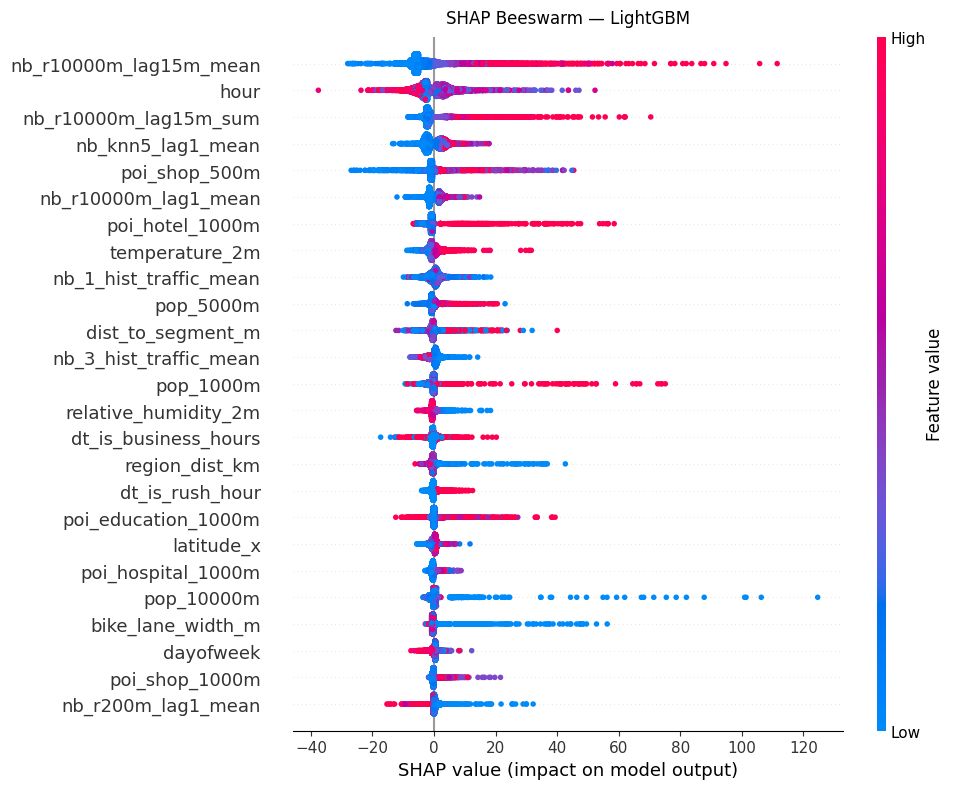

In [ ]:
#SHAP Analysis
# Create the SHAP summary (beeswarm) plot without showing it yet
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_cols,
    max_display=25,
    show=False,
    plot_size=(10, 8),   # give it an explicit size instead of None
)

# Grab the current figure/axes that SHAP just created
fig = plt.gcf()
ax = plt.gca()

# Now set the title on the correct axes
ax.set_title(f"SHAP Beeswarm — {_shap_model_name}", fontsize=12, pad=10)

plt.tight_layout()
plt.show()


In [ ]:
# ── Feature Selection

CUMULATIVE_THRESHOLD = 90
# Find number of features to keep based on cumulative SHAP importance
n_keep = int((df_shap["cumulative%"] >= CUMULATIVE_THRESHOLD).idxmax()) + 1
selected_feature_cols = df_shap.head(n_keep)["feature"].tolist()

n_total   = len(feature_cols)
n_dropped = n_total - n_keep

print(f"Threshold  : top {CUMULATIVE_THRESHOLD}% cumulative SHAP importance")
print(f"Keep    : {n_keep} % {n_total} features  ({n_keep/n_total*100:.1f}%)")
print(f"Remove   : {n_dropped} features")

# Features dropped
dropped_features = df_shap.iloc[n_keep:][["rank", "feature", "mean_abs_shap", "cumulative%"]]
print(f"\n── Dropped features (mean |SHAP| lowest) ──")
print(dropped_features.to_string(index=False))

# Rebuild X_train / X_test with selected features
X_train_sel = X_train[selected_feature_cols]
X_test_sel  = X_test[selected_feature_cols]
print(f"\nX_train_sel shape: {X_train_sel.shape}")
print(f"X_test_sel  shape: {X_test_sel.shape}")


Threshold  : top 90% cumulative SHAP importance
Keep    : 44 % 90 features  (48.9%)
Remove   : 46 features

── Dropped features (mean |SHAP| lowest) ──
 rank                            feature  mean_abs_shap  cumulative%
   45                            site_nr       0.293354        90.71
   46                nb_r10000m_lag1_sum       0.268605        91.21
   47              nb_r10000m_lag15m_max       0.256989        91.70
   48                        longitude_y       0.256986        92.18
   49                   nb_knn5_lag1_sum       0.256906        92.66
   50                      poi_shop_250m       0.251979        93.14
   51                    nb_r5000m_count       0.215824        93.54
   52                    sensor_age_days       0.210459        93.94
   53         nb_5_hist_traffic_mean_avg       0.209395        94.34
   54              nb_r10000m_lag15m_std       0.186023        94.69
   55                        cloud_cover       0.182858        95.03
   56               

In [ ]:
# Retrain with selected features
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def _eval(model, X, y, label):
    pred = np.clip(model.predict(X), 0, None)
    return {
        "model":   label,
        "n_feat":  X.shape[1],
        "MAE":     round(mean_absolute_error(y, pred), 4),
        "RMSE":    round(np.sqrt(mean_squared_error(y, pred)), 4),
        "R2":      round(r2_score(y, pred), 4),
    }

rows = []

# Baseline: best model with full feature set
rows.append(_eval(_best_model, X_test, y_test,
                  f"{_best_name} (full {len(feature_cols)} features)"))

# Retrain with selected features only
print(f"Retraining {_shap_model_name} với {len(selected_feature_cols)} features...")
model_sel = clone(_shap_model)
model_sel.fit(X_train_sel, y_train)
rows.append(_eval(model_sel, X_test_sel, y_test,
                  f"{_shap_model_name} (selected {len(selected_feature_cols)} features)"))

# Test more: best model different from  selected features
if _best_name != _shap_model_name:
    model_best_sel = clone(_best_model)
    model_best_sel.fit(X_train[selected_feature_cols], y_train)
    rows.append(_eval(model_best_sel, X_test[selected_feature_cols], y_test,
                      f"{_best_name} (selected {len(selected_feature_cols)} features)"))

df_compare = pd.DataFrame(rows)
print("\nFeature Selection Comparison")
print(df_compare.to_string(index=False))

delta_mae = rows[1]["MAE"] - rows[0]["MAE"]
sign = "+" if delta_mae > 0 else ""
print(f"\nΔ MAE after feature selection: {sign}{delta_mae:.4f}")

# Update feature_cols to use in section 4 (hyperparameter tuning)
print(f"\n→ Use selected_feature_cols ({len(selected_feature_cols)} features) "
      f"for hyperparameter tuning in Section 4")


Retraining LightGBM với 44 features...

── Feature Selection Comparison ──
                          model  n_feat    MAE    RMSE     R2
    LightGBM (full 90 features)      90 6.4674 14.2039 0.8845
LightGBM (selected 44 features)      44 6.4929 14.2237 0.8842

Δ MAE after feature selection: +0.0255

→ Use selected_feature_cols (44 features) for hyperparameter tuning in Section 4


## 5. Hyperparameters Tuning

In [ ]:
# LightGBM Hyperparameter Tuning (GPU-accelerated)

import subprocess, time
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform, loguniform

try:
    from lightgbm import LGBMRegressor
except ImportError:
    raise ImportError("pip install lightgbm")

# GPU automatic detection
try:
    _smi = subprocess.run(["nvidia-smi"], capture_output=True, timeout=3)
    _HAS_GPU = _smi.returncode == 0
except Exception:
    _HAS_GPU = False

if _HAS_GPU:
    lgb_device_params = dict(
        device="gpu",
        gpu_platform_id=0,
        gpu_device_id=0,
        num_threads=1,
    )
    _search_n_jobs = 1
    print("GPU detected")
else:
    lgb_device_params = dict(
        device="cpu",
        num_threads=-1,
    )
    _search_n_jobs = 1
    print("Don't have GPU")

# Sort by time
order       = df_model.loc[X_train_sel.index, "datehour"].sort_values().index
X_tr_sorted = X_train_sel.loc[order]
y_tr_sorted = y_train.loc[order]

# Search space
param_dist_lgb = {
    "n_estimators":      randint(200, 700),
    "learning_rate":     loguniform(0.01, 0.15),
    "num_leaves":        randint(20, 150),
    "max_depth":         [-1, 6, 8, 10, 12],
    "min_child_samples": randint(20, 150),
    "subsample":         uniform(0.6, 0.4),          # 0.6 – 1.0
    "colsample_bytree":  uniform(0.6, 0.4),
    "reg_alpha":         loguniform(1e-4, 1.0),      # L1
    "reg_lambda":        loguniform(1e-4, 1.0),      # L2
    "min_split_gain":    uniform(0.0, 0.5),
}

base_lgb = LGBMRegressor(
    objective="regression",
    random_state=42,
    verbose=-1,
    **lgb_device_params,
)

lgb_search = RandomizedSearchCV(
    estimator=base_lgb,
    param_distributions=param_dist_lgb,
    n_iter=10,
    cv=TimeSeriesSplit(n_splits=4),
    scoring="neg_mean_absolute_error",
    n_jobs=_search_n_jobs,
    random_state=42,
    verbose=1,
    refit=True,
)

print(f"\nStarting LightGBM RandomizedSearchCV (10 iters × 4 folds = 40 fits)...")
t0 = time.time()
lgb_search.fit(X_tr_sorted, y_tr_sorted)
print(f"Done in {time.time()-t0:.1f}s")

print(f"\n Best CV MAE : {-lgb_search.best_score_:.4f}")
print(" Best params :")
for k, v in sorted(lgb_search.best_params_.items()):
    print(f"   {k:<22} = {v}")

tuned_lgb = lgb_search.best_estimator_

# Evaluate on test set
lgb_pred = np.clip(tuned_lgb.predict(X_test_sel), 0, None)
print(f"\n Test set (2026)  "
      f"MAE={mean_absolute_error(y_test, lgb_pred):.4f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_test, lgb_pred)):.4f}  "
      f"R2={r2_score(y_test, lgb_pred):.4f}")

# Top-10 CV iterations
cv_df = (
    pd.DataFrame(lgb_search.cv_results_)
    [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .assign(cv_mae=lambda d: -d["mean_test_score"],
            cv_std=lambda d:  d["std_test_score"])
    .sort_values("cv_mae")
    .head(10)
    .reset_index(drop=True)
)
print("\n Top-10 iterations (CV MAE)")
cv_df[["rank_test_score", "cv_mae", "cv_std", "params"]]


# Compare tuned LightGBM with the untuned LightGBM from the model-selection section
tuned_lgb_scores = {
    "model": "LightGBM_Tuned",
    "fit_seconds": np.nan,
    "MAE": mean_absolute_error(y_test, lgb_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, lgb_pred)),
    "R2": r2_score(y_test, lgb_pred),
}

df_results_with_tuned = (
    pd.concat([df_results, pd.DataFrame([tuned_lgb_scores])], ignore_index=True)
    .sort_values("MAE")
    .reset_index(drop=True)
)

trained["LightGBM_Tuned"] = tuned_lgb

print("\n Top-10 iterations (CV MAE)")
display(df_results_with_tuned)


✓ GPU detected — LightGBM sẽ dùng GPU



Starting LightGBM RandomizedSearchCV (10 iters × 4 folds = 40 fits)...
Fitting 4 folds for each of 10 candidates, totalling 40 fits
Done in 942.2s

 Best CV MAE : 7.8697
 Best params :
   colsample_bytree       = 0.8404460046972835
   learning_rate          = 0.06803900745073706
   max_depth              = 12
   min_child_samples      = 21
   min_split_gain         = 0.36099938613341237
   n_estimators           = 613
   num_leaves             = 57
   reg_alpha              = 0.00010071984838809202
   reg_lambda             = 0.9307782732027226
   subsample              = 0.8469926038510867

 Test set (2026)  MAE=5.5871  RMSE=12.1514  R2=0.9155

 Top-10 iterations (CV MAE)

 Top-10 iterations (CV MAE)


,model,fit_seconds,MAE,RMSE,R2
0,LightGBM_Tuned,NaN,5.587080,12.151444,0.915500
1,LightGBM,19.9,6.467424,14.203915,0.884544
2,HistGradientBoosting,30.0,6.587693,14.349268,0.882169
3,Baseline_Mean,0.0,23.142344,41.996624,-0.009317
